In [2]:
from pyheteromap import PyHeteroMap
h = PyHeteroMap(seq_name="SMOKE_TEST")
print("ok:", h.seq_name)


Note: The first 10 frames in the trajectory were skipped.

ok: SMOKE_TEST


In [1]:
import pandas as pd
import mdtraj as md
import numpy as np
import os
import afrc
from numpy import linalg as la
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from itertools import chain
from scipy import spatial
from matplotlib.ticker import MaxNLocator
from numpy import linspace
import random as rd

In [3]:
import Bio

In [5]:
import sys, importlib, platform

print("Python:", sys.version)
print("Platform:", platform.platform())

mods = [
    "pandas","numpy","afrc","scipy","matplotlib","random",
    "IPython","ipykernel","jupyter_core","jupyter_client",'Bio',"notebook","mdtraj"
]
for m in mods:
    if m!='mdtraj' and m!="os":
        try:
            mod = importlib.import_module(m)
            ver = getattr(mod, "__version__", "unknown")
            print(f"{m}: {ver}")
        except Exception as e:
            print(f"{m}: not available ({e})")
    elif m=='mdtraj':
        print('\nFor mdtraj, here are the details:')
        !pip3 show mdtraj

Python: 3.9.18 (main, Jan 26 2024, 16:04:25) 
[GCC 8.5.0 20210514 (Red Hat 8.5.0-20)]
Platform: Linux-4.18.0-477.10.1.el8_8.x86_64-x86_64-with-glibc2.28
pandas: 2.2.2
numpy: 1.26.4
afrc: v0.3.4
scipy: 1.13.1
matplotlib: 3.9.1
random: unknown
IPython: 8.18.1
ipykernel: 6.29.5
jupyter_core: 5.7.2
jupyter_client: 8.6.2
Bio: 1.84
notebook: 7.2.1

For mdtraj, here are the details:
Name: mdtraj
Version: 1.10.0
Summary: MDTraj: A modern, open library for the analysis of molecular dynamics trajectories
Home-page: http://mdtraj.org
Author: Robert McGibbon
Author-email: rmcgibbo@gmail.com
License: LGPLv2.1+
Location: /home/hshadman/.local/lib/python3.9/site-packages
Requires: astunparse, numpy, packaging, pyparsing, scipy
Required-by: soursop


In [16]:
class PyHeteroMap:
    def __init__(self,seq_name,
             gw_reference_csv="../segmented_chain_project/reference_GW_chainlen_100_for_RSA.csv",
             traj_file_dir=None, prmtop_file_dir=None,
             skip_frames=10,
             afrc_returns_angstrom=True):
    
        self.gw_reference_csv = gw_reference_csv
        print(f'Note: The first {skip_frames} frames in the trajectory were skipped.\n')
        self.skip_frames = skip_frames
        self.afrc_returns_angstrom = afrc_returns_angstrom

        self.gw_df = None     
    
        self.protein_df = None
        self.fC_value = None
        self.grid_protein = None
        self.grid_GW = None    
        self._traj_full = None     
        self._traj = None          
        self._n_residues = None
        self._first_atom_index = None
        self._last_atom_index = None
        self._subchain_df = None
        self.seq_name = str(seq_name)
        
        if traj_file_dir and prmtop_file_dir:
            self.set_trajectory(traj_file_dir, prmtop_file_dir)

    def _load_gw_reference(self):
        if self.gw_df is not None:
            print(f"GW data already present (source: {getattr(self, 'gw_source', 'unknown')}). Skipping reload.\n")
            return
    
        if not os.path.exists(self.gw_reference_csv):
            raise FileNotFoundError(f"GW reference CSV not found at: {self.gw_reference_csv}")
    
        try:
            df = pd.read_csv(self.gw_reference_csv)
        except Exception as e:
            raise ValueError(f"Failed to load GW reference CSV: {e}")
    
        if df.empty:
            raise ValueError("GW reference CSV is empty.")
    
        self.gw_df = df.copy()
        self.gw_source = "reference"
        print(f"Loaded reference GW chain from: {self.gw_reference_csv}\n")

    def reinitialize_gw_reference(self):
    
        if not os.path.exists(self.gw_reference_csv):
            raise FileNotFoundError(f"GW reference CSV not found at: {self.gw_reference_csv}")
    
        try:
            df = pd.read_csv(self.gw_reference_csv)
        except Exception as e:
            raise ValueError(f"Failed to load GW reference CSV: {e}")
    
        if df.empty:
            raise ValueError("GW reference CSV is empty.")
    
        self.gw_df = df.copy()
        self.gw_source = "reference"
        print(f"Loaded reference GW chain from: {self.gw_reference_csv}\n")    
    
    def set_trajectory(self, traj_file_dir, prmtop_file_dir):
        t = md.load(traj_file_dir, top=prmtop_file_dir)
        self._traj_full = t
        self._traj = t[self.skip_frames:]
        self._n_residues = t.topology.n_residues
        print('The code as written is for CG simulations (one "bead" per amino acid residue).\n')
        print('If all-atom, users may want CA atoms instead:\n')
        print('self._first_atom_index = t.topology.select("name CA and residue 0")[0]')
        print('self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]\n')
        print('Modify accordingly in set_trajectory and inside the subchain loop in initialize_30mer_subchain.')
        self._first_atom_index = t.topology.select(f"residue {0}")[0]
        self._last_atom_index  = t.topology.select(f"residue {self._n_residues - 1}")[0]
        self._ree_series_nm = md.compute_distances(self._traj,atom_pairs= [[self._first_atom_index, self._last_atom_index]]).flatten()
        self._subchain_df = None
        if self._traj.topology.n_atoms != self._traj.topology.n_residues:
            print("Warning: all-atom topology detected. Switch to CA atoms as noted in set_trajectory() to get meaningful ν.")

    
        
    def mod_RSA_Rs_compute_3dplot_from_seq_name(self, provided_color='magenta'):
        print('Data loading...\n')
        if self._traj_full is None or self._traj is None:
            raise RuntimeError("Call set_trajectory(...) before this method.")
        t = self._traj
        t_df_moments = pd.DataFrame(md.principal_moments(t),columns=['R3','R2','R1']).copy()
        t_df_moments['asphericity']=t_df_moments.R1.values-(0.5*(t_df_moments.R2.values+t_df_moments.R3.values))
        t_df_moments['acylindricity']=t_df_moments.R2.values-t_df_moments.R3.values
        t_df_moments['RSA']=(t_df_moments.asphericity.values**2+(0.75*t_df_moments.acylindricity.values**2))/(t_df_moments.R1.values+t_df_moments.R2.values+t_df_moments.R3.values)**2
        self.protein_df = t_df_moments[['RSA']].copy()
        del t_df_moments
        self.protein_df['Rg2'] = md.compute_rg(t)**2
        self.protein_df['Ree2'] = self._ree_series_nm**2
        self.protein_df['ratio'] = self.protein_df['Ree2']/self.protein_df['Rg2']
        print('Data loaded. Visualizing now, this could take some time.')
        return self.mod_RSA_Rs_protein_3dplot_against_GW(self.protein_df, self.seq_name, 'protein', provided_color)
    @staticmethod
    def RSA_based_fC(protein_var,protein_name,poly_id,
                           GW_moment_var,every_ith_snap,GW_every_ith_snap,radius_):
        x_total=[]
        y_total=[]
        if poly_id=='protein':
            protein_label=protein_name
            temp_protein=protein_var.copy()
            x_total.append(temp_protein.RSA.values)
            y_total.append(temp_protein.ratio.values)
            x_total=list(chain.from_iterable(x_total))
            y_total=list(chain.from_iterable(y_total))
            poly_var=protein_var.copy()
            protein_pro=poly_var[['ratio','RSA']].iloc[:every_ith_snap,:].copy()
            protein_pro['polymer_id']=np.repeat(protein_label,protein_pro.shape[0])
            del x_total, y_total, temp_protein
    
        elif poly_id=='polymer':
            print('protein_var MUST be single epas')
            protein_label=protein_name
            temp_protein=protein_var.copy()
            x_total.append(temp_protein.RSA.values)
            y_total.append(temp_protein.ratio.values)
            x_total=list(chain.from_iterable(x_total))
            y_total=list(chain.from_iterable(y_total))
            poly_var=protein_var.copy()
            protein_pro=poly_var[['ratio','RSA']].iloc[:every_ith_snap,:].copy()
            protein_pro['polymer_id']=np.repeat(protein_label,protein_pro.shape[0])
            del x_total, y_total, temp_protein
        
        
        elif poly_id=='pei':
            print('protein_var MUST be single proton state')
            protein_label='pei_'+ str(protein_name)
            temp_protein=protein_var.copy() # temp_protein isn't really needed but just adding
            poly_var=protein_var.copy()
            protein_pro=poly_var[['ratio','RSA']].iloc[:every_ith_snap,:].copy()
            protein_pro['polymer_id']=np.repeat(protein_label,protein_pro.shape[0])
            del x_total, y_total, temp_protein
        else:
            return print('ERROR')
        
        
        GW_po=GW_moment_var[['ratio','RSA']][::GW_every_ith_snap].copy()
        GW_po['polymer_id']=np.repeat('GW',GW_po.shape[0])
        
        #calculate mean and stdev values for data transformation on the scatter plot
        # Mean and standard deviation for GW are calculated using 1000000 snapshots.
        #If you wish to change that, just change upto_snapshots.
        upto_snapshots=1000000
        GW_mean_ratio=np.mean(GW_po['ratio'].values[0:(upto_snapshots+1)])
        GW_std_ratio=np.std(GW_po['ratio'].values[0:(upto_snapshots+1)])
        GW_mean_RSA=np.mean(GW_po['RSA'].values[0:(upto_snapshots+1)])
        GW_std_RSA=np.std(GW_po['RSA'].values[0:(upto_snapshots+1)])
            
        combined_pro_po=pd.concat([GW_po,protein_pro],axis=0,ignore_index=True)
        combined_pro_po['stdd_ratio']=(combined_pro_po['ratio'].values-GW_mean_ratio)/(GW_std_ratio)
        combined_pro_po['stdd_RSA']=(combined_pro_po['RSA'].values-GW_mean_RSA)/(GW_std_RSA)
        po_x=combined_pro_po[combined_pro_po.polymer_id=='GW']['stdd_RSA'].values
        po_y=combined_pro_po[combined_pro_po.polymer_id=='GW']['stdd_ratio'].values
        pro_x=combined_pro_po[combined_pro_po.polymer_id==protein_label]['stdd_RSA'].values
        pro_y=combined_pro_po[combined_pro_po.polymer_id==protein_label]['stdd_ratio'].values
        
        GW_points=np.c_[po_x, po_y]
        protein_points=np.c_[pro_x, pro_y]    
        tree_GW=spatial.cKDTree(GW_points)
        tree_protein=spatial.cKDTree(protein_points)
    
        GW_not_in_range=[]
        j=0
        for point in GW_points:
    
            if not tree_protein.query_ball_point(point,radius_):
                GW_not_in_range.append(point)
            j+=1
            if j%500000==0:
                print(f'{j} GW snapshots processed')
                    
        fC_by_distance=(GW_points.shape[0]-len(GW_not_in_range))/(GW_points.shape[0])
        return fC_by_distance    

    def mod_RSA_Rs_protein_3dplot_against_GW(self,protein_var,protein_label,second_obj,provided_color):
        
        x_variable= 'RSA'
        y_variable=r'$R_s$'
        
        self._load_gw_reference()
        
        if self.gw_df is None:
            raise ValueError("GW data not initialized. Load or regenerate before analysis.")

        testeq_GW = self.gw_df
        
        nu_val, nu_err = self.calculate_nu_KLL_from_seq_name(1, self._n_residues)
        
        plt.rcParams["font.weight"] = "regular"
        plt.rcParams["axes.labelweight"] = "regular"
        
        
        x_polmodel_GW=[]
        y_polmodel_GW=[]
        x_total=[]
        y_total=[]
    
        scatter_markers=['d','x',4,'o','v','^','1','8','s','p','P','*','X','D',9]
    
    
        x_polmodel_GW.append(testeq_GW['RSA'].values)
        y_polmodel_GW.append(testeq_GW['ratio'].values)
    
        if second_obj=='protein':        
            temp_protein =  protein_var.copy()
    
            x_total.append(temp_protein.RSA.values)
            y_total.append(temp_protein.ratio.values)
    
            self.fC_value=PyHeteroMap.RSA_based_fC(temp_protein,
                           protein_label,
                           second_obj,testeq_GW,
                           temp_protein.shape[0],
                           1,0.1)            
            del temp_protein
        else:
            print('ERROR. FIX ERROR')
    
        x_total=list(chain.from_iterable(x_total))
        y_total=list(chain.from_iterable(y_total))
        x_polmodel_GW=list(chain.from_iterable(x_polmodel_GW))
        y_polmodel_GW=list(chain.from_iterable(y_polmodel_GW))
    
        # Set up default x and y limits
        max_x_val=1
        max_y_val=30
        if testeq_GW['RSA'].max()>max_x_val:
            max_x_val = testeq_GW['RSA'].max()
        if testeq_GW['RSA'].min()<0:
            return print('ERROR. GW RSA has a negative value.')
        if max(x_total)>max_x_val:
            max_x_val = max(x_total)
        if min(x_total)<0:
            return print('ERROR. RSA for your protein/polymer has a negative value.')        
        if testeq_GW['ratio'].max()>max_y_val :
            max_y_val = testeq_GW['ratio'].max()
        if testeq_GW['ratio'].min()<0:
            return print('ERROR. GW shape ratio has a negative value.')
        if max(y_total)>max_y_val:
            max_y_val = max(y_total)
        if min(y_total)<0:
            return print('ERROR. shape ratio for your protein/polymer has a negative value.')        
        
        xlims = [0,max_x_val]
        ylims = [0,max_y_val]

        # Set up your x and y labels
        xlabel = x_variable
        ylabel = y_variable
    
        # Define the locations for the axes
    
        left, width = 0.12, 0.55
        bottom, height = 0.12, 0.55
        bottom_h = left_h = left+width
        rect_temperature = [left, bottom, width, height] # dimensions of temp plot
        rect_histx = [left, bottom_h, width, 0.25] # dimensions of x-histogram
        rect_histy = [left_h, bottom, 0.25, height] # dimensions of y-histogram
    
    
        # Set up the size of the figure
        fig = plt.figure(figsize=(3.2,3))
    
        # Make the three plots
        axTemperature = fig.add_axes(rect_temperature) # temperature plot
        axHistx = fig.add_axes(rect_histx) # x histogram
        axHisty = fig.add_axes(rect_histy) # y histogram
    
    
        axHistx.axes.get_xaxis().set_visible(False)
        axHisty.axes.get_yaxis().set_visible(False)
    
    
        # Find the min/max of the data
        xmin = min(xlims)
        xmax = max(xlims)
        ymin = min(ylims)
        ymax = max(ylims)
    
        # Remove the inner axes numbers of the histograms
        #nullfmt = NullFormatter()
        #
        # Define the number of bins
        nxbins = 100
        nybins = 50
        nbins = nxbins+nybins
    
        xbins = linspace(start = xmin, stop = xmax, num = nxbins)
        ybins = linspace(start = ymin, stop = ymax, num = nybins)
        #xcenter = (xbins[0:-1]+xbins[1:])/2.0
        #ycenter = (ybins[0:-1]+ybins[1:])/2.0
        #aspectratio = (1.0*(xmax - 0))/(1.38*ymax - 0)
    
    
        #X = xcenter
        #Y = ycenter
    
        axTemperature.scatter(x_polmodel_GW,y_polmodel_GW,
                          marker=scatter_markers[3],s=1,alpha=0.6,color='black',
                           label='GW')
        
        axTemperature.scatter(x_total,
                   y_total,
                   marker=scatter_markers[0],s=1,alpha=0.6,color=provided_color,
                                          label=protein_label)                
    
    
    
        #Plot the axes labels
        axTemperature.set_xlabel(xlabel,fontsize=12,labelpad = 1)
        axTemperature.set_ylabel(ylabel,fontsize=12, labelpad = 1)
    
        #Set up the plot limits
        axTemperature.set_xlim(xlims)
        axTemperature.set_ylim(ylims)
    
        #Set up the histogram bins
        xbins = np.arange(xmin, xmax, (xmax-xmin)/nbins)
        ybins = np.arange(ymin, ymax, (ymax-ymin)/nbins)
    
    
        axHistx.hist(x_polmodel_GW, bins=xbins, color = 'black',histtype='step',
                    linewidth = 0.7,density=True)
        axHistx.hist(x_total, bins=xbins, color = provided_color,histtype='step',
                    label=protein_label,linewidth = 0.7,density=True)
        
        _bins_hy = np.arange(min(y_total), max(y_total), 1)
        if _bins_hy.size < 2:
            _bins_hy = linspace(min(y_total), max(y_total), 20)  #fallback
        
        axHisty.hist(y_polmodel_GW, bins=_bins_hy, color = 'black',orientation='horizontal',histtype='step',
                    linewidth = 0.7,density=True)

        
        axHisty.hist(y_total, bins=ybins, color = provided_color,orientation='horizontal',histtype='step',
                    label=protein_label,linewidth = 0.7,density=True)    
        
       
        step_x=0.02
        step_y=0.6
        max_value_x=max(xlims)
        n_divisions_x=round((max_value_x-min(xlims))/step_x)
        
        max_value_y=max(ylims)
        n_divisions_y=round((max_value_y-min(ylims))/step_y)
        gridx = np.linspace(min(xlims), max(xlims), n_divisions_x)
        gridy = np.linspace(min(ylims), max(ylims), n_divisions_y)
        
        self.grid_protein, _, _ = np.histogram2d(x_total, y_total, bins=[gridx, gridy])
        self.grid_GW, _, _ = np.histogram2d(x_polmodel_GW, y_polmodel_GW, bins=[gridx, gridy])
    
        axTemperature.text(1.03,1.12,
                           r'$f_{C\_shape}$ = '+format(self.fC_value,'0.3f'),
                          transform=axTemperature.transAxes,fontsize=8)
        
        axTemperature.text(1.03,1.05,
                               f"$\\nu$ = {nu_val:0.3f}",
                              transform=axTemperature.transAxes,fontsize=8)    
        axTemp_legend=axTemperature.legend(fontsize=7,loc=(1.01,1.19),borderpad = 0.03,
                                           labelspacing = 0.05, handlelength  = 1,frameon=False,
                                           handletextpad = 0.005)
    
        frame = axTemp_legend.get_frame()
        frame.set_linewidth(1)
        frame.set_edgecolor('black')
        
        #Set up the histogram limits
        axHistx.set_xlim( xmin, xmax )
        axHisty.set_ylim( ymin, ymax )
    
        axHistx.set_ylabel('Prob. Dens.',fontsize=11)
        axHisty.set_xlabel('Prob. Dens.',fontsize=11)
    
    
        
        axHisty.xaxis.set_major_locator(MaxNLocator(4))
        axHistx.yaxis.set_major_locator(MaxNLocator(3))
    
        for i in ['top', 'left', 'right', 'bottom']:
            axHistx.spines[i].set_linewidth(1)
            axHisty.spines[i].set_linewidth(1)
            axTemperature.spines[i].set_linewidth(1)
    
        axHistx.minorticks_on()
        axHistx.tick_params(axis='y', which='major', labelsize=10, width = 0.8, pad = 2)
        axHistx.tick_params(axis='y', which='minor', width = 0.6)
        axHisty.minorticks_on()
        axHisty.tick_params(axis='x', which='major', labelsize=10, width = 0.8, pad = 2,labelrotation=270)
        axHisty.tick_params(axis='x', which='minor', width = 0.6)
        axTemperature.minorticks_on()
        axTemperature.tick_params(axis='both', which='major', labelsize=10, width = 0.8, pad = 2)
        axTemperature.tick_params(axis='both', which='minor', width = 0.6)    
        plt.setp(axTemperature.get_yticklabels()[-1], visible=False)
        plt.setp(axTemperature.get_xticklabels()[-1], visible=False)
        return 
#subchain functions
    def initialize_30mer_subchain(self, fasta_source,k_frac=3):
        print('NOTE: Subchain calculation might take longer for longer peptides/IDRs.\n')
        print('NOTE: If peptide length is smaller than 5 residues, nu cannot be computed.\n')
        if self._traj is None:
            raise RuntimeError("Call set_trajectory(traj_file, prmtop_file) before this method.")
        traj = self._traj
        """
        fasta_source:
          - If 'IDR_fasta_sequences.csv', the function reads it and extracts fasta_sequence by seq_name.
          - If a path ending in '.fasta' or '.fa', it reads the FASTA file directly.
          - If a plain string (sequence of AAs), it uses that directly.
          - If None, raises an error.
        """
    
        if fasta_source is None:
            raise ValueError("You must provide either a FASTA file path or raw sequence via 'fasta_source'.")
    
        if fasta_source.lower().endswith('.csv'):
            print('If the fasta sequences in the csv file are arranged differently,'
                  'modify this section of the code to properly read in fasta_sequence.\n')
            idrome_prop_flucs = pd.read_csv(fasta_source)
            subset = idrome_prop_flucs[idrome_prop_flucs.seq_name==self.seq_name]
            if subset.empty:
                raise ValueError(f"{self.seq_name} not found in {fasta_source}.")
            fasta_sequence = subset.fasta.values[0]
            
            
        elif str(fasta_source).lower().endswith(('.fasta','.fa')):
            try:
                from Bio import SeqIO
            except ImportError as e:
                raise ImportError("Reading FASTA requires Biopython. Install with: pip install biopython") from e
            recs = list(SeqIO.parse(str(fasta_source), 'fasta'))
            if not recs:
                raise ValueError(f"No records found in FASTA file: {fasta_source}")
            # try to match seq_name; else first record
            rec = next((r for r in recs if (r.id == self.seq_name) or (self.seq_name in r.description)), recs[0])
            fasta_sequence = str(rec.seq).strip().upper()
        
        elif all(res.upper() in "ACDEFGHIKLMNPQRSTVWY" for res in fasta_source):
            fasta_sequence = fasta_source
        
        else:
            raise ValueError(f"Unrecognized fasta_source: {fasta_source}")
        
        
        n_residues = self._n_residues
        if len(fasta_sequence) != n_residues:
            raise ValueError(f"Residue count mismatch: FASTA has {len(fasta_sequence)}, trajectory has {traj.topology.n_residues}.")

        
        print('If <= 60 residues, the moving window is ~1/3rd (by default) of the number of residues.')
        print('If > 60 residues, the moving window is 30 residues.\n')
        if len(fasta_sequence) <= 60:
            if not isinstance(k_frac, (int, float)) or k_frac <= 0:
                raise ValueError("k_frac must be positive.")
            k = round(traj.topology.n_residues/k_frac)
        elif len(fasta_sequence) > 60:
            k = 30
            
    
        
        complete_protein_rgyr = np.mean(md.compute_rg(traj))
        complete_protein_nu = self.calculate_nu_KLL_from_seq_name( 1, n_residues)[0]
        complete_protein_nu_err = self.calculate_nu_KLL_from_seq_name( 1, n_residues)[1]
        end_to_end_distances = self._ree_series_nm
        complete_protein_ete = end_to_end_distances
        complete_protein_inst_ratio = np.mean(complete_protein_ete**2/md.compute_rg(traj)**2)
        
        complete_protein_moments = pd.DataFrame(md.principal_moments(traj),columns=['R3','R2','R1']).copy()
        complete_protein_moments['asphericity']=complete_protein_moments.R1.values-(0.5*(complete_protein_moments.R2.values+complete_protein_moments.R3.values))
        complete_protein_moments['acylindricity']=complete_protein_moments.R2.values-complete_protein_moments.R3.values
        complete_protein_moments['RSA']=(complete_protein_moments.asphericity.values**2+(0.75*complete_protein_moments.acylindricity.values**2))/(complete_protein_moments.R1.values+complete_protein_moments.R2.values+complete_protein_moments.R3.values)**2
        complete_protein_RSA = np.mean(complete_protein_moments['RSA'].values)    
    
        #AFRC
        complete_protein_afrc_init = afrc.AnalyticalFRC(fasta_sequence)
        print('AFRC calculates in Angstrom units.')
        print('Since MDTraj calculations are in nm units, a conversion variable "scale" is applied.')
        print('If needed, modify the "scale" variable in initialize_30mer_subchain.\n')
        complete_protein_rg_theta_mean = complete_protein_afrc_init.get_mean_radius_of_gyration()
        scale = 10.0 if self.afrc_returns_angstrom else 1.0
        complete_protein_rg_rg_theta_mean = np.mean((scale*md.compute_rg(traj))/complete_protein_rg_theta_mean)
    
        
        j = 0
        # Iterate through each subsequence of k residues        
        for start_res in range(1, n_residues - k + 2):  # Ensures we don't go out of bounds
            # Select k consecutive residues
            selection_string = f"residue {start_res-1} to {start_res + k - 2}"  # MDTraj is zero-indexed
            subsequence_indices = traj.topology.select(selection_string)
            
            fasta_slice = fasta_sequence[(start_res-1):(start_res + k - 1)]
            running_df = pd.DataFrame(np.repeat(fasta_slice,traj.n_frames),columns=['fasta_sequence'])
            running_df['start_res_zeroindex'] = np.repeat(start_res-1,traj.n_frames)
            running_df['end_res_zeroindex'] = np.repeat(start_res + k - 2,traj.n_frames)
            running_df['full_protein_fasta'] = np.repeat(fasta_sequence,traj.n_frames)
    
            running_df['full_protein_rgyr'] = np.repeat(complete_protein_rgyr,traj.n_frames)
            running_df['full_protein_nu_recompute'] = np.repeat(complete_protein_nu,traj.n_frames)
            running_df['full_protein_nu_recompute_err'] = np.repeat(complete_protein_nu_err,traj.n_frames)
            running_df['full_protein_ratio'] = np.repeat(complete_protein_inst_ratio,traj.n_frames)
            running_df['full_protein_RSA'] = np.repeat(complete_protein_RSA,traj.n_frames)
            running_df['full_protein_rg_rg_theta_mean'] = np.repeat(complete_protein_rg_rg_theta_mean,traj.n_frames)
            
            running_df['seq_name'] = np.repeat(self.seq_name,traj.n_frames)
            # Create a trajectory slice for the selected subsequence
            subsequence_traj = traj.atom_slice(subsequence_indices)
            
            # Calculate the radius of gyration for the subsequence over all remaining frames
            rgyr = md.compute_rg(subsequence_traj)
            running_df['Rg/nm'] = rgyr
    
            #calculate nu
            subsequence_nu, subsequence_nu_err = self.calculate_nu_KLL_from_seq_name( start_res, start_res + k - 1)
            
            running_df['nu_recompute'] = np.repeat(subsequence_nu,traj.n_frames)
            running_df['nu_recompute_err'] = np.repeat(subsequence_nu_err,traj.n_frames)
            
            # Select indices for the first and last bead in the subsequence for end-to-end distance calculation
            first_bead_index = traj.topology.select(f"residue {start_res-1}")[0]
            last_bead_index = traj.topology.select(f"residue {start_res + k - 2}")[0]
        
            # Calculate end-to-end distances for the subsequence over all remaining frames
            end_to_end_distances = md.compute_distances(traj, [[first_bead_index, last_bead_index]])
            end_to_end_distances = end_to_end_distances.flatten()
            running_df['ete'] = end_to_end_distances
            running_df['inst_ratio'] = (running_df['ete'].values**2)/(running_df['Rg/nm'].values**2)
            
            t_df_moments = pd.DataFrame(md.principal_moments(subsequence_traj),columns=['R3','R2','R1']).copy()
            t_df_moments['asphericity']=t_df_moments.R1.values-(0.5*(t_df_moments.R2.values+t_df_moments.R3.values))
            t_df_moments['acylindricity']=t_df_moments.R2.values-t_df_moments.R3.values
            t_df_moments['RSA']=(t_df_moments.asphericity.values**2+(0.75*t_df_moments.acylindricity.values**2))/(t_df_moments.R1.values+t_df_moments.R2.values+t_df_moments.R3.values)**2
            running_df['RSA'] = t_df_moments['RSA'].values
    
            #AFRC
            afrc_init = afrc.AnalyticalFRC(fasta_slice)
            rg_theta_mean = afrc_init.get_mean_radius_of_gyration()
            running_df['AFRC_mean_rg_theta'] = np.repeat(rg_theta_mean,traj.n_frames)
            running_df['rg_rg_theta_mean'] = (scale*running_df['Rg/nm'].values)/running_df['AFRC_mean_rg_theta'].values
            
            if j == 0:
                master_df = running_df.copy()
            elif j>0:
                master_df = pd.concat([master_df,running_df],axis=0).copy()
            del running_df, t_df_moments
            #print(f"residue {start_res-1} to {start_res + k - 2} done")
            j+=1
        print('Subchain data generated.\n')    
        self._subchain_df = master_df.copy()
        return master_df
        
    def calculate_nu_KLL_from_seq_name(self, start_residue, end_residue):
        if self._traj is None:
            raise RuntimeError("Call set_trajectory(traj_file, prmtop_file) before this method.")
        t_md = self._traj
        
        subsequence_indices = t_md.topology.select(f'residue {start_residue-1} to {end_residue-1}')
        
        subsequence_traj = t_md.atom_slice(subsequence_indices)
    
        ij, dij, nu, nu_err, R0, R0_err = PyHeteroMap.Rij(subsequence_traj)
        return nu, nu_err

    #Rij is from Tesei et al. 2024 (Title: conformational ensembles of the human intrinsically disordered proteome)
    @staticmethod
    def Rij(traj):
        pairs = traj.top.select_pairs('all','all')
        d = md.compute_distances(traj,pairs)
        nres = traj.n_atoms
        ij = np.arange(2,nres,1)
        diff = [x[1]-x[0] for x in pairs]
        dij = np.empty(0)
        for i in ij:
            dij = np.append(dij,np.sqrt((d[:,diff==i]**2).mean().mean()))
        f = lambda x,R0,v : R0*np.power(x,v)
        popt, pcov = curve_fit(f,ij[ij>5],dij[ij>5],p0=[.4,.5])
        nu = popt[1]
        nu_err = pcov[1,1]**0.5
        R0 = popt[0]
        R0_err = pcov[0,0]**0.5
        return ij,dij,nu,nu_err,R0,R0_err
    #assign_properties categorizes amino acids 
    @staticmethod
    def assign_properties(residue):
        properties = {
            'negative': ['E', 'D'],
            'positive': ['R', 'K'],
            'apolar': ['Y', 'F','A', 'W','I', 'L', 'M', 'V','P','G','C'],
            'polar': ['S','T','Q','N','H']
        }
        colors = {
            'negative': 'red',
            'positive': 'blue',
            'apolar': 'yellow',
            'polar': 'white'  
        }
        size = 0
        color = 'black'
        for prop, residues in properties.items():
            if residue in residues:
                color = colors[prop]
                size = 80  # Adjust size for visual distinction
                break
        return color, size
    @staticmethod
    def _subchain_RSA_plot(df,figwidth,figheight):
        # Calculate the midpoint for plotting and the properties for each midpoint
        df['mid_residue'] = (df['start_res_zeroindex'] + df['end_res_zeroindex']) // 2
        df[['color', 'size']] = df.apply(lambda row: PyHeteroMap.assign_properties(row['full_protein_fasta'][row['mid_residue']]),
                                         axis=1, result_type='expand')
        
        # Group by 'mid_residue' to calculate mean, standard deviation and get the most common color and size
        stats_rsa = df.groupby('mid_residue').agg({
            'RSA': ['mean', 'std'],
            'color': lambda x: x.mode()[0],
            'size': lambda x: x.mode()[0]
        }).reset_index()
        
        # Flatten the MultiIndex
        stats_rsa.columns = ['mid_residue', 'mean', 'std', 'color', 'size']
        
        fig, ax = plt.subplots(figsize=(figwidth,figheight))
        
        # Plotting
        ax.plot(stats_rsa['mid_residue'], stats_rsa['mean'], color='black', zorder=1)
        ax.fill_between(stats_rsa['mid_residue'], 
                         stats_rsa['mean'] - (stats_rsa['std']/2), 
                         stats_rsa['mean'] + (stats_rsa['std']/2), 
                         color='gray', alpha=0.2, zorder=1)
        
        global_var = df.full_protein_RSA.unique()[0]
        if global_var>=np.min(ax.get_ylim()) and global_var<=np.max(ax.get_ylim()):
            ax.axhline(y=global_var, color='black', linestyle='--')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold')
        else:
            fig.text(0.12, 0.879, fr'Global $\langle RSA \rangle$ = {format(global_var, "0.2f")}',
                 fontsize=12, verticalalignment='bottom', horizontalalignment='left')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold',pad = 22)
        
        
        # Adjust scatter plot to use different sizes and colors with higher zorder
        for i, row in stats_rsa.iterrows():
            ax.scatter(row['mid_residue'], row['mean'], color=row['color'], s=row['size'], zorder=2,edgecolors='black', linewidths=1)
        
        ax.set_xlabel('Residue', fontsize=12)
        ax.set_ylabel(r'Local $\langle RSA \rangle$', fontsize=12)
        
        
        # Customizing the plot border thickness
        for spine in ['top', 'left', 'right', 'bottom']:
            ax.spines[spine].set_linewidth(1.2)
        
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', labelsize=10, width=0.75, pad=2)
        ax.tick_params(axis='both', which='minor', width=0.6)
        
        # Create custom legend with circles and edge color for white patch
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Negative (E/D)', markersize=10, markerfacecolor='red',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Positive (R/K)', markersize=10, markerfacecolor='blue',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Apolar (Y/F/A/W/I/L/M/V/P/G/C)', markersize=10, markerfacecolor='yellow',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Polar (S/T/Q/N/H)', markersize=10, markerfacecolor='white',
                  markeredgewidth=1, markeredgecolor='black')  
        ]
        
        # Adding the legend with the custom entries
        ax.legend(handles=legend_elements, loc=(1.01,0.6))
        return
    @staticmethod
    def _subchain_Rs_plot(df,figwidth,figheight):
        # Calculate the midpoint for plotting and the properties for each midpoint
        df['mid_residue'] = (df['start_res_zeroindex'] + df['end_res_zeroindex']) // 2
        df[['color', 'size']] = df.apply(lambda row: PyHeteroMap.assign_properties(row['full_protein_fasta'][row['mid_residue']]),
                                         axis=1, result_type='expand')
        
        # Group by 'mid_residue' to calculate mean, standard deviation and get the most common color and size
        stats_rs = df.groupby('mid_residue').agg({
            'inst_ratio': ['mean', 'std'],
            'color': lambda x: x.mode()[0],
            'size': lambda x: x.mode()[0]
        }).reset_index()
        
        # Flatten the MultiIndex
        stats_rs.columns = ['mid_residue', 'mean', 'std', 'color', 'size']
        
        fig, ax = plt.subplots(figsize=(figwidth,figheight))
        
        # Plotting
        ax.plot(stats_rs['mid_residue'], stats_rs['mean'], color='black', zorder=1)
        ax.fill_between(stats_rs['mid_residue'], 
                         stats_rs['mean'] - (stats_rs['std']/2), 
                         stats_rs['mean'] + (stats_rs['std']/2), 
                         color='gray', alpha=0.2, zorder=1)
    
        global_var = df.full_protein_ratio.unique()[0]
        if global_var>=np.min(ax.get_ylim()) and global_var<=np.max(ax.get_ylim()):
            ax.axhline(y=global_var, color='black', linestyle='--')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold')
        else:
            fig.text(0.12, 0.879, fr'Global $\langle R_s \rangle$ = {format(global_var, "0.2f")}',
                     fontsize=12, verticalalignment='bottom', horizontalalignment='left')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold',pad = 22)
        
        # Adjust scatter plot to use different sizes and colors with higher zorder
        for i, row in stats_rs.iterrows():
            ax.scatter(row['mid_residue'], row['mean'], color=row['color'], s=row['size'], zorder=2,edgecolors='black', linewidths=1)
        
        ax.set_xlabel('Residue', fontsize=12)
        ax.set_ylabel(r'Local $\langle R_s \rangle$', fontsize=12)
        
        
        # Customizing the plot border thickness
        for spine in ['top', 'left', 'right', 'bottom']:
            ax.spines[spine].set_linewidth(1.2)
        
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', labelsize=10, width=0.75, pad=2)
        ax.tick_params(axis='both', which='minor', width=0.6)
        
        # Create custom legend with circles and edge color for white patch
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Negative (E/D)', markersize=10, markerfacecolor='red',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Positive (R/K)', markersize=10, markerfacecolor='blue',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Apolar (Y/F/A/W/I/L/M/V/P/G/C)', markersize=10, markerfacecolor='yellow',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Polar (S/T/Q/N/H)', markersize=10, markerfacecolor='white',
                  markeredgewidth=1, markeredgecolor='black')  
        ]
        
        # Adding the legend with the custom entries
        ax.legend(handles=legend_elements, loc=(1.01,0.6))
        return
    @staticmethod
    def _subchain_Rg_plot(df,figwidth,figheight):
        print('Rg unit will depend on the data. In the examples it is nm, so a nm label is used.')
        # Calculate the midpoint for plotting and the properties for each midpoint
        df['mid_residue'] = (df['start_res_zeroindex'] + df['end_res_zeroindex']) // 2
        df[['color', 'size']] = df.apply(lambda row: PyHeteroMap.assign_properties(row['full_protein_fasta'][row['mid_residue']]),
                                         axis=1, result_type='expand')
        
        # Group by 'mid_residue' to calculate mean, standard deviation and get the most common color and size
        stats_rg = df.groupby('mid_residue').agg({
            'Rg/nm': ['mean', 'std'],
            'color': lambda x: x.mode()[0],
            'size': lambda x: x.mode()[0]
        }).reset_index()
        
        # Flatten the MultiIndex
        stats_rg.columns = ['mid_residue', 'mean', 'std', 'color', 'size']
    
        fig, ax = plt.subplots(figsize=(figwidth, figheight))
        
        # Plotting
        ax.plot(stats_rg['mid_residue'], stats_rg['mean'], color='black', zorder=1)
        ax.fill_between(stats_rg['mid_residue'], 
                         stats_rg['mean'] - (stats_rg['std']/2), 
                         stats_rg['mean'] + (stats_rg['std']/2), 
                         color='gray', alpha=0.2, zorder=1)
        global_var = df.full_protein_rgyr.unique()[0]
        if global_var>=np.min(ax.get_ylim()) and global_var<=np.max(ax.get_ylim()):
            ax.axhline(y=global_var, color='black', linestyle='--')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold')
        else:
            fig.text(0.12, 0.879, fr'Global $\langle R_g \rangle$ (nm) = {format(global_var, "0.2f")} nm',
                     fontsize=12, verticalalignment='bottom', horizontalalignment='left')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold',pad = 22)
        
        # Adjust scatter plot to use different sizes and colors with higher zorder
        for i, row in stats_rg.iterrows():
            ax.scatter(row['mid_residue'], row['mean'], color=row['color'], s=row['size'], zorder=2,edgecolors='black', linewidths=1)
        
        ax.set_xlabel('Residue', fontsize=12)
        ax.set_ylabel(r'Local $\langle R_g \rangle$ (nm)', fontsize=12)
        
        
        # Customizing the plot border thickness
        for spine in ['top', 'left', 'right', 'bottom']:
            ax.spines[spine].set_linewidth(1.2)
        
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', labelsize=10, width=0.75, pad=2)
        ax.tick_params(axis='both', which='minor', width=0.6)
        
        # Create custom legend with circles and edge color for white patch
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Negative (E/D)', markersize=10, markerfacecolor='red',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Positive (R/K)', markersize=10, markerfacecolor='blue',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Apolar (Y/F/A/W/I/L/M/V/P/G/C)', markersize=10, markerfacecolor='yellow',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Polar (S/T/Q/N/H)', markersize=10, markerfacecolor='white',
                  markeredgewidth=1, markeredgecolor='black')  
        ]
        
        # Adding the legend with the custom entries
        ax.legend(handles=legend_elements, loc=(1.01,0.6))
        return 
    @staticmethod
    def _subchain_Rg_Rg_theta_mean_plot(df,figwidth,figheight):
        print("This is computing a ⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ plot.")
        print("⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ is also referred to as ⟨α⟩ in the associated paper.")
        print("⟨R₍g₎ᶿ⟩ was computed directly from sequence using an Analytical Flory Random Coil (AFRC) reference, Alston et al. 2023")
    
    
        # Calculate the midpoint for plotting and the properties for each midpoint
        df['mid_residue'] = (df['start_res_zeroindex'] + df['end_res_zeroindex']) // 2
        df[['color', 'size']] = df.apply(lambda row: PyHeteroMap.assign_properties(row['full_protein_fasta'][row['mid_residue']]),
                                         axis=1, result_type='expand')
        
        # Group by 'mid_residue' to calculate mean, standard deviation and get the most common color and size
        stats_rsa = df.groupby('mid_residue').agg({
            'rg_rg_theta_mean': ['mean', 'std'],
            'color': lambda x: x.mode()[0],
            'size': lambda x: x.mode()[0]
        }).reset_index()
        
        # Flatten the MultiIndex
        stats_rsa.columns = ['mid_residue', 'mean', 'std', 'color', 'size']
        
        fig, ax = plt.subplots(figsize=(figwidth,figheight))
        
        # Plotting
        ax.plot(stats_rsa['mid_residue'], stats_rsa['mean'], color='black', zorder=1)
        ax.fill_between(stats_rsa['mid_residue'], 
                         stats_rsa['mean'] - (stats_rsa['std']/2), 
                         stats_rsa['mean'] + (stats_rsa['std']/2), 
                         color='gray', alpha=0.2, zorder=1)
    
        global_var = df.full_protein_rg_rg_theta_mean.unique()[0]
        if global_var>=np.min(ax.get_ylim()) and global_var<=np.max(ax.get_ylim()):
            ax.axhline(y=global_var, color='black', linestyle='--')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold')
        else:
            fig.text(0.12, 0.879, rf'Global $\langle R_g / \langle R_g^\theta \rangle\rangle$'+f' = {format(global_var, "0.2f")}',
                     fontsize=12, verticalalignment='bottom', horizontalalignment='left')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold',pad = 24)
        
        # Adjust scatter plot to use different sizes and colors with higher zorder
        for i, row in stats_rsa.iterrows():
            ax.scatter(row['mid_residue'], row['mean'], color=row['color'], s=row['size'], zorder=2,edgecolors='black', linewidths=1)
        
        ax.set_xlabel('Residue', fontsize=12)
        ax.set_ylabel(r'Local $\langle R_g / \langle R_g^\theta \rangle\rangle$', fontsize=12)
    
        # Customizing the plot border thickness
        for spine in ['top', 'left', 'right', 'bottom']:
            ax.spines[spine].set_linewidth(1.2)
        
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', labelsize=10, width=0.75, pad=2)
        ax.tick_params(axis='both', which='minor', width=0.6)
        
        # Create custom legend with circles and edge color for white patch
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Negative (E/D)', markersize=10, markerfacecolor='red',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Positive (R/K)', markersize=10, markerfacecolor='blue',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Apolar (Y/F/A/W/I/L/M/V/P/G/C)', markersize=10, markerfacecolor='yellow',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Polar (S/T/Q/N/H)', markersize=10, markerfacecolor='white',
                  markeredgewidth=1, markeredgecolor='black')  
        ]
        
        # Adding the legend with the custom entries
        ax.legend(handles=legend_elements, loc=(1.01,0.6))
        return
    @staticmethod
    def _subchain_nu_plot(df,figwidth,figheight):
        print('nu formula is from Tesei et al. 2024')
        # Calculate the midpoint for plotting and the properties for each midpoint
        df['mid_residue'] = (df['start_res_zeroindex'] + df['end_res_zeroindex']) // 2
        df[['color', 'size']] = df.apply(lambda row: PyHeteroMap.assign_properties(row['full_protein_fasta'][row['mid_residue']]),
                                         axis=1, result_type='expand')
        
        # Group by 'mid_residue' to calculate mean, standard deviation and get the most common color and size
        stats_rsa = df.groupby('mid_residue').agg({
            'nu_recompute': ['mean'],
            'nu_recompute_err': ['mean'],
            'color': lambda x: x.mode()[0],
            'size': lambda x: x.mode()[0]
        }).reset_index()
        
        # Flatten the MultiIndex
        stats_rsa.columns = ['mid_residue', 'mean', 'std', 'color', 'size']
        
        fig, ax = plt.subplots(figsize=(figwidth,figheight))
        
        # Plotting
        ax.plot(stats_rsa['mid_residue'], stats_rsa['mean'], color='black', zorder=1)
        ax.fill_between(stats_rsa['mid_residue'], 
                         stats_rsa['mean'] - (stats_rsa['std']/2), 
                         stats_rsa['mean'] + (stats_rsa['std']/2), 
                         color='gray', alpha=0.2, zorder=1)
    
        global_var = df.full_protein_nu_recompute.unique()[0]
        if global_var>=np.min(ax.get_ylim()) and global_var<=np.max(ax.get_ylim()):
            ax.axhline(y=global_var, color='black', linestyle='--')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold')
        else:
            fig.text(0.12, 0.879, r'Global $\nu$'+f' = {format(global_var, "0.3f")}',
                     fontsize=12, verticalalignment='bottom', horizontalalignment='left')
            ax.set_title(df.seq_name.unique()[0], loc='left', fontsize=12, fontweight='bold',pad = 24)
        
        # Adjust scatter plot to use different sizes and colors with higher zorder
        for i, row in stats_rsa.iterrows():
            ax.scatter(row['mid_residue'], row['mean'], color=row['color'], s=row['size'], zorder=2,edgecolors='black', linewidths=1)
        
        ax.set_xlabel('Residue', fontsize=12)
        ax.set_ylabel(r'Local $\nu$', fontsize=12)
        
        # Customizing the plot border thickness
        for spine in ['top', 'left', 'right', 'bottom']:
            ax.spines[spine].set_linewidth(1.2)
        
        ax.minorticks_on()
        ax.tick_params(axis='both', which='major', labelsize=10, width=0.75, pad=2)
        ax.tick_params(axis='both', which='minor', width=0.6)
        
        # Create custom legend with circles and edge color for white patch
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label='Negative (E/D)', markersize=10, markerfacecolor='red',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Positive (R/K)', markersize=10, markerfacecolor='blue',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Apolar (Y/F/A/W/I/L/M/V/P/G/C)', markersize=10, markerfacecolor='yellow',
                  markeredgewidth=1, markeredgecolor='black'),
            Line2D([0], [0], marker='o', color='w', label='Polar (S/T/Q/N/H)', markersize=10, markerfacecolor='white',
                  markeredgewidth=1, markeredgecolor='black')  
        ]
        
        # Adding the legend with the custom entries
        ax.legend(handles=legend_elements, loc=(1.01,0.6))
        return
    def plot_subchain_RSA(self, figwidth, figheight):
        if self._subchain_df is None:
            raise RuntimeError("No subchain data. Call initialize_30mer_subchain(fasta_source, k_frac=...) first.")
        PyHeteroMap._subchain_RSA_plot(self._subchain_df, figwidth, figheight)
        
    def plot_subchain_Rs(self, figwidth, figheight):
        if self._subchain_df is None:
            raise RuntimeError("No subchain data. Call initialize_30mer_subchain(fasta_source, k_frac=...) first.")
        PyHeteroMap._subchain_Rs_plot(self._subchain_df, figwidth, figheight)
    
    def plot_subchain_Rg(self, figwidth, figheight):
        if self._subchain_df is None:
            raise RuntimeError("No subchain data. Call initialize_30mer_subchain(fasta_source, k_frac=...) first.")
        PyHeteroMap._subchain_Rg_plot(self._subchain_df, figwidth, figheight)
    
    def plot_subchain_Rg_over_Rgtheta(self, figwidth, figheight):
        if self._subchain_df is None:
            raise RuntimeError("No subchain data. Call initialize_30mer_subchain(fasta_source, k_frac=...) first.")
        PyHeteroMap._subchain_Rg_Rg_theta_mean_plot(self._subchain_df, figwidth, figheight)
    
    def plot_subchain_nu(self, figwidth, figheight):
        if self._subchain_df is None:
            raise RuntimeError("No subchain data. Call initialize_30mer_subchain(fasta_source, k_frac=...) first.")
        PyHeteroMap._subchain_nu_plot(self._subchain_df, figwidth, figheight)

#GW code
    @staticmethod
    def _gw_calculate_tensors(x,y,z,chain_length):
        xx = np.sum((x-np.mean(x))*(x-np.mean(x)))/chain_length
        xy = np.sum((x-np.mean(x))*(y-np.mean(y)))/chain_length
        xz = np.sum((x-np.mean(x))*(z-np.mean(z)))/chain_length
        yx = np.sum((y-np.mean(y))*(x-np.mean(x)))/chain_length
        yy = np.sum((y-np.mean(y))*(y-np.mean(y)))/chain_length 
        yz = np.sum((y-np.mean(y))*(z-np.mean(z)))/chain_length 
        zx = np.sum((z-np.mean(z))*(x-np.mean(x)))/chain_length 
        zy = np.sum((z-np.mean(z))*(y-np.mean(y)))/chain_length
        zz = np.sum((z-np.mean(z))*(z-np.mean(z)))/chain_length
        
        Sij = np.array([[xx,xy,xz],
                       [yx,yy,yz],
                       [zx,zy,zz]])
        return Sij
        
    @staticmethod
    def _gw_Ree2(x,y,z):
        return ((x[0]-x[len(x)-1])**2+(y[0]-y[len(y)-1])**2+(z[0]-z[len(z)-1])**2)
        
    @staticmethod
    def _gw_Rgx2(x,chain_length): 
        Rgx = np.sum((x - np.mean(x))**2)/chain_length
        return Rgx
    @staticmethod
    def _gw_Rgy2(y,chain_length): 
        Rgy = np.sum((y - np.mean(y))**2)/chain_length
        return Rgy
    @staticmethod
    def _gw_Rgz2(z,chain_length): 
        Rgz = np.sum((z - np.mean(z))**2)/chain_length
        return Rgz    
    
    @staticmethod
    def _gw_diagonalize_tensor(rg_tensors):
        tensor_df = pd.DataFrame()
        for i in rg_tensors.index:
            temp_mat = np.zeros((3,3))
            temp_mat[0,:] = rg_tensors.loc[i,['XX','XY','XZ']].values
            temp_mat[1,:] = rg_tensors.loc[i,['XY','YY','YZ']].values
            temp_mat[2,:] = rg_tensors.loc[i,['XZ','YZ','ZZ']].values
            temp_mat = pd.DataFrame(np.sort(la.eig(temp_mat)[0].real)[::-1]).T
            temp_mat.columns = ['R1','R2','R3']
            tensor_df = pd.concat([tensor_df,temp_mat])
        tensor_df.reset_index(drop=True)
        return tensor_df.reset_index(drop=True)
    
    
    def regenerate_GW_chain(self,chain_length,nosnaps,interval=1,mu=0,sigma=1):
        chain_length = int(chain_length)
        nosnaps = int(nosnaps)
        interval = int(interval)
        chain_length=chain_length
        x = np.zeros(chain_length)
        y = np.zeros(chain_length)
        z = np.zeros(chain_length)
        x_coor=[]
        y_coor=[]
        z_coor=[]
        nosnaps = nosnaps
        interval=interval
        snapshot=0
        mu = mu
        sigma = sigma 
        Rend2 = []
        rg_tensors=pd.DataFrame(columns=['XX','XY','XZ','YX','YY','YZ','ZX','ZY','ZZ'])
        Rg2 = []
        shape_ratio=[]
        while snapshot<(nosnaps*interval):
            mean_sq_disp_i = []
            for i in range(1,chain_length,1):
                x[i] = x[i-1] + rd.gauss(mu,sigma)
                y[i] = y[i-1] + rd.gauss(mu,sigma)
                z[i] = z[i-1] + rd.gauss(mu,sigma)        
                mean_sq_disp_i.append((x[i]-x[0])**2)
            if snapshot in np.arange(0,(nosnaps*interval),interval):
                Rend2.append(self._gw_Ree2(x,y,z))
                Rg2.append(self._gw_Rgx2(x,chain_length)+self._gw_Rgy2(y,chain_length)+self._gw_Rgz2(z,chain_length))
                shape_ratio.append(self._gw_Ree2(x,y,z)/(self._gw_Rgx2(x,chain_length)+self._gw_Rgy2(y,chain_length)+self._gw_Rgz2(z,chain_length)))
                rg_tensors.loc[len(rg_tensors)]=self._gw_calculate_tensors(x,y,z,chain_length).flatten()
                x_coor.append(list(x))
                y_coor.append(list(y))
                z_coor.append(list(z))
            snapshot = snapshot + 1   
        print(f'chain_length={chain_length}, Nosnaps={nosnaps}, interval= {interval}')   
        master_out=pd.DataFrame(np.array([Rg2,
                           Rend2,
                           shape_ratio]).T,columns=['Rg2','Rend2','ratio'])
        master_out.insert(0,'chain_length',np.repeat(chain_length,nosnaps))
        master_out['x']=x_coor
        master_out['y']=y_coor
        master_out['z']=z_coor
        gauss_chain_df = master_out.copy()
        diagonalized= self._gw_diagonalize_tensor(rg_tensors)
        diagonalized['asphericity']=diagonalized.R1.values-(0.5*(diagonalized.R2.values+diagonalized.R3.values))
        diagonalized['acylindricity']=diagonalized.R2.values-diagonalized.R3.values
        diagonalized['RSA']=(diagonalized.asphericity.values**2+(0.75*diagonalized.acylindricity.values**2))/((diagonalized.R1.values+diagonalized.R2.values+diagonalized.R3.values)**2)
        final_df = pd.concat([gauss_chain_df,diagonalized],axis=1).copy()
        del diagonalized, gauss_chain_df, master_out
        self.gw_df = final_df
        self.gw_source = "regenerated"
        print("New GW chain generated and stored in self.gw_df.")
        print("To save, call export_gw_csv('GW_regenerated.csv').")
        return 
    def export_gw_csv(self, out_path):
    
        if self.gw_df is None:
            raise ValueError("No GW data available to export. Generate or load first.")
    
        try:
            self.gw_df.to_csv(out_path, index=False)
        except Exception as e:
            raise IOError(f"Failed to save GW CSV: {e}")
    
        print(f"GW chain successfully saved to: {out_path}")



In [11]:
test_idr1 = PyHeteroMap(seq_name='Q8WV44_43_186',
             traj_file_dir='traj1.xtc', prmtop_file_dir='top1.pdb')


Note: The first 10 frames in the trajectory were skipped.

The code as written is for CG simulations (one "bead" per amino acid residue).

If all-atom, users may want CA atoms instead:

self._first_atom_index = t.topology.select("name CA and residue 0")[0]
self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]

Modify accordingly in set_trajectory and inside the subchain loop in initialize_30mer_subchain.


Data loading...

Data loaded. Visualizing now, this could take some time.
GW data already present (source: reference). Skipping reload.

500000 GW snapshots processed
1000000 GW snapshots processed


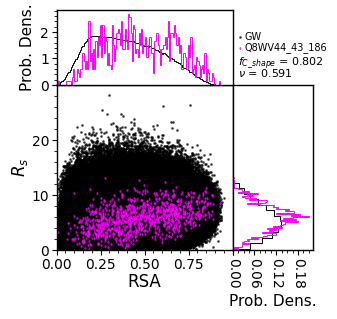

In [15]:
test_idr1.mod_RSA_Rs_compute_3dplot_from_seq_name('magenta')

In [14]:
test_idr1._reinitialize_gw_reference()

Loaded reference GW chain from: ../segmented_chain_project/reference_GW_chainlen_100_for_RSA.csv



NOTE: Subchain calculation might take longer for longer peptides/IDRs.

NOTE: If peptide length is smaller than 5 residues, nu cannot be computed.

If the fasta sequences in the csv file are arranged differently,modify this section of the code to properly read in fasta_sequence.

If <= 60 residues, the moving window is ~1/3rd (by default) of the number of residues.
If > 60 residues, the moving window is 30 residues.

AFRC calculates in Angstrom units.
Since MDTraj calculations are in nm units, a conversion variable "scale" is applied.
If needed, modify the "scale" variable in initialize_30mer_subchain.

Subchain data generated.



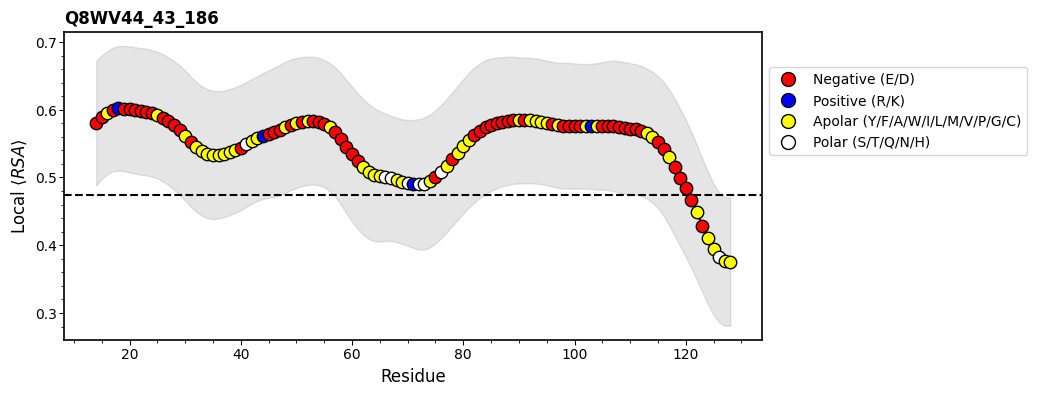

In [35]:
test_idr1.initialize_30mer_subchain('IDR_fasta_sequences.csv')
test_idr1.plot_subchain_RSA(9,4)

In [12]:
test_idr1.regenerate_GW_chain(100,10000)
test_idr1.gw_df

chain_length=100, Nosnaps=10000, interval= 1
New GW chain generated and stored in self.gw_df.
To save, call export_gw_csv('GW_regenerated.csv').


,chain_length,Rg2,Rend2,ratio,x,y,z,R1,R2,R3,asphericity,acylindricity,RSA
0,100,93.866843,602.999569,6.423989,"[0.0, -0.9771438010091545, -1.4800966635690673...","[0.0, -0.37138179227243906, 1.3154418568937492...","[0.0, 0.13482250554805983, 2.9059846027045757,...",86.970979,4.185443,2.710421,83.523048,1.475022,0.791936
1,100,82.978210,597.186823,7.196911,"[0.0, -0.7442199098369306, -0.6222765422908203...","[0.0, -1.6816019459504055, -3.726201899395128,...","[0.0, 2.1634989256654262, 1.2072573447492019, ...",70.579669,8.552413,3.846128,64.380399,4.706285,0.604389
2,100,25.315929,226.179891,8.934292,"[0.0, 0.8590012044632671, 1.5585472989930254, ...","[0.0, 0.009816302018963496, -1.862545395852692...","[0.0, -0.07369554343832299, 1.4445047823302335...",15.439718,6.197234,3.678977,10.501612,2.518257,0.179499
3,100,54.784595,393.713399,7.186571,"[0.0, -0.5625916504875829, -0.5864984791063432...","[0.0, 0.39762154364432567, -0.3561537387631639...","[0.0, 0.8204563184043506, 0.2575647953761102, ...",40.363202,12.376321,2.045072,33.152506,10.331249,0.392870
4,100,36.887762,153.970688,4.174032,"[0.0, 1.0967414338585537, 1.3206954565943492, ...","[0.0, -0.4632422491988727, -0.5006143008477202...","[0.0, 0.7531845903045249, 1.3910432619838455, ...",30.164617,3.960282,2.762863,26.803044,1.197419,0.528753
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,100,52.863340,398.188808,7.532419,"[0.0, -0.40564495876648715, -1.797978226212564...","[0.0, -0.16447151601238563, 0.6312469874869898...","[0.0, 0.3471025039545534, 0.7804254462880036, ...",43.211991,6.522173,3.129176,38.386316,3.392997,0.530373
9996,100,41.882201,227.456935,5.430874,"[0.0, 0.8378294181255811, -0.1378608583011005,...","[0.0, -1.1274502070236037, -0.0862248476376958...","[0.0, 0.0022531797102372216, 0.663657734969249...",32.411232,5.422028,4.048941,27.675748,1.373087,0.437462
9997,100,56.677418,468.457856,8.265335,"[0.0, 0.320587214774552, 1.5098000080076468, 2...","[0.0, 1.1257861097106017, 2.0000718923456895, ...","[0.0, 0.4897757343947458, 3.333296324660105, 3...",44.444839,9.594056,2.638524,38.328549,6.955531,0.468620
9998,100,95.808243,562.186765,5.867833,"[0.0, -0.7484078994334056, -0.3529241550004517...","[0.0, 1.225888258036667, 2.5404845875725, 2.17...","[0.0, -0.8797858311495066, -0.9893177855384553...",48.532531,44.908831,2.366881,24.894675,42.541950,0.215390


In [37]:
test_idr1.mod_RSA_Rs_compute_3dplot_from_seq_name('magenta')

Data loading...

Data loaded. Visualizing now, this could take some time.
GW data already present (source: regenerated). Skipping reload.

ERROR. There is an issue with x or y-axis limits.


This is computing a ⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ plot.
⟨R₍g₎ / ⟨R₍g₎ᶿ⟩⟩ is also referred to as ⟨α⟩ in the associated paper.
⟨R₍g₎ᶿ⟩ was computed directly from sequence using an Analytical Flory Random Coil (AFRC) reference, Alston et al. 2023


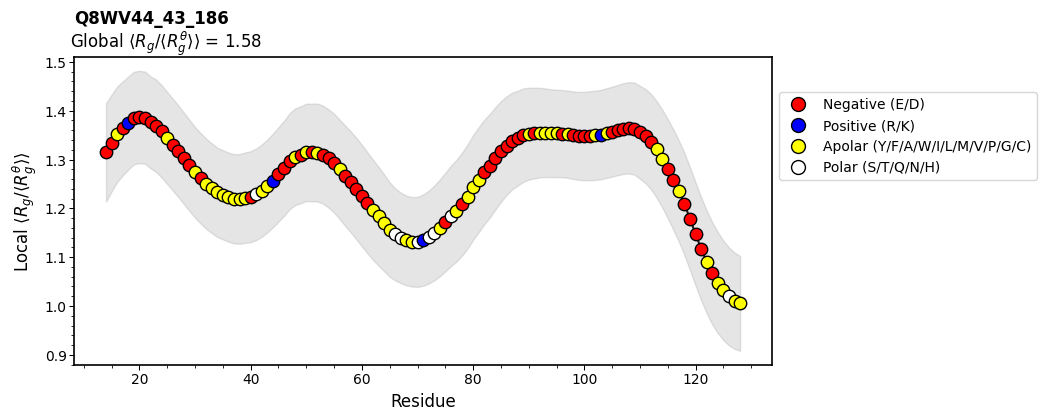

In [77]:
test_idr.plot_subchain_Rg_over_Rgtheta(9,4)

Rg unit will depend on the data. In the examples it is nm, so a nm label is used.


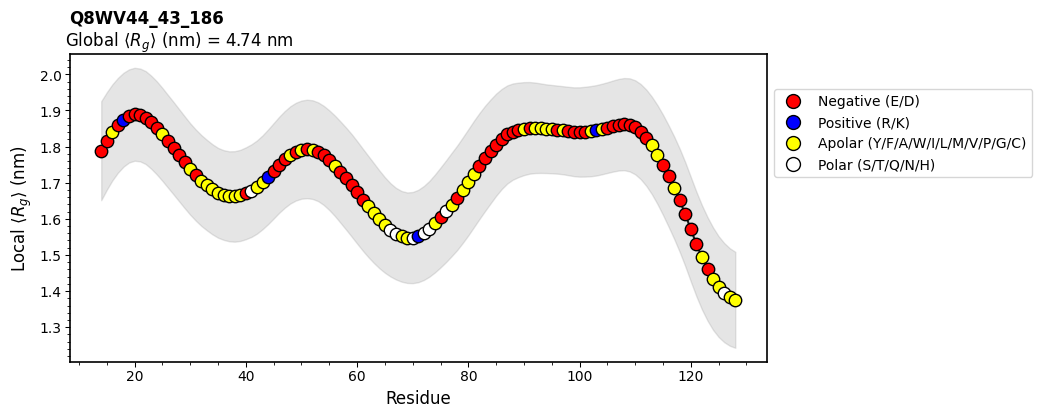

In [81]:
test_idr.plot_subchain_Rg(9,4)

Note: The first 10 in the trajectory were skipped.
The code as written is for coarse-grained simulations (one "bead" per amino acid residue).

Modify self._first_atom_index and self._last_atom_index in the set_trajectory function accordingly
if other types of simulations are used.

If all-atom, users may want CA atoms instead:
self._first_atom_index = t.topology.select("name CA and residue 0")[0]
self._last_atom_index  = t.topology.select(f"name CA and residue {self._n_residues - 1}")[0]

Data loading...

Data loaded. Visualizing now, this could take some time.
Note: If peptide length is smaller than 5 residues, nu cannot be computed.

Mean and standard deviation for GW are calculated using 1000000 snapshots.
If you wish to change that, just change upto_snapshots.

500000 GW snapshots processed
1000000 GW snapshots processed


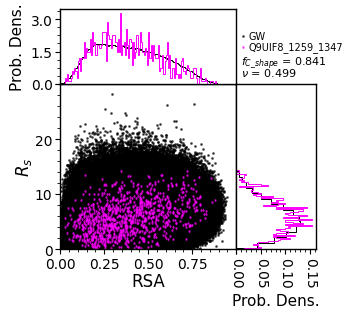

In [20]:
test_idr = PyHeteroMap(
             gw_reference_csv="../segmented_chain_project/reference_GW_chainlen_100_for_RSA.csv",
             traj_file_dir='traj2.xtc', prmtop_file_dir='top2.pdb',
             skip_frames=10,
             afrc_returns_angstrom=True)
test_idr.mod_RSA_Rs_compute_3dplot_from_seq_name('Q9UIF8_1259_1347','magenta')

# GW code

In [18]:
np.zeros(100)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [92]:

gauss_chain_100 = regenerate_GW_chain(100,1000,1,0,1)


chain_length=100, Nosnaps=1000, interval= 1


In [105]:
diagonalized= diagonalize_tensor(rg_tensors)
diagonalized['asphericity']=diagonalized.R1.values-(0.5*(diagonalized.R2.values+diagonalized.R3.values))
diagonalized['acylindricity']=diagonalized.R2.values-diagonalized.R3.values
diagonalized['RSA']=(diagonalized.asphericity.values**2+(0.75*diagonalized.acylindricity.values**2))/((diagonalized.R1.values+diagonalized.R2.values+diagonalized.R3.values)**2)


In [117]:
rg_tensors

,XX,XY,XZ,YX,YY,YZ,ZX,ZY,ZZ
0,73.324432,2.822196,48.570516,2.822196,4.930378,-4.748343,48.570516,-4.748343,60.335472
1,9.364064,-7.576514,-2.761868,-7.576514,17.750115,-0.405390,-2.761868,-0.405390,7.582455
2,4.601943,-1.553122,-4.728004,-1.553122,22.837568,-4.713437,-4.728004,-4.713437,13.305559
3,5.019513,0.646584,3.401711,0.646584,3.017007,-0.121854,3.401711,-0.121854,4.972412
4,9.829850,-10.591096,-5.662374,-10.591096,19.917090,6.532932,-5.662374,6.532932,7.163674
...,...,...,...,...,...,...,...,...,...
995,20.599112,14.077708,-28.305462,14.077708,13.426065,-23.356079,-28.305462,-23.356079,48.693187
996,56.717681,17.303380,-2.902851,17.303380,12.818289,0.272616,-2.902851,0.272616,12.799191
997,13.836126,6.916057,0.874004,6.916057,13.023328,0.313810,0.874004,0.313810,5.850033
998,28.708881,-3.610079,1.799473,-3.610079,5.742540,-4.194185,1.799473,-4.194185,10.602868


In [109]:
pd.concat([gauss_chain_100,
          diagonalized],axis=1).ratio.mean()

5.72274894032776

In [110]:
gauss = pd.read_csv('../segmented_chain_project/reference_GW_chainlen_100_for_RSA.csv')
gauss

,chain_length,Rg2,Rg2_1by4,Rg2_2by4,Rg2_3by4,Rg2_4by4,Rg2_1by2,Rg2_2by2,Rend2,ratio,ratio1by4,ratio2by4,ratio3by4,ratio4by4,ratio1by2,ratio2by2,x,y,z,RSA
0,100,52.145267,31.956371,23.287430,20.262910,14.489398,60.633043,40.666586,182.079302,3.491770,6.792823,3.321035,4.259448,3.048247,5.168367,6.192105,"[0.0, -1.3792551413339786, 0.6401116060484824,...","[0.0, 0.6918487289137815, 0.3302358800332237, ...","[0.0, -0.135867321633138, 0.829329943949159, 0...",0.267987
1,100,121.803163,12.120736,19.398466,41.474573,31.510322,42.672739,61.973894,1191.389612,9.781270,5.162156,11.473278,7.532891,8.355203,8.954668,7.228705,"[0.0, 0.06688285919394767, 0.9571999716903222,...","[0.0, -0.1667189016236574, -2.662670674998852,...","[0.0, -0.6064473508500713, -0.9005961753905372...",0.431904
2,100,40.959984,25.753887,13.575531,8.958946,5.233011,34.026087,14.378811,363.603205,8.877035,11.098705,3.306340,2.300558,3.263106,8.092359,3.242365,"[0.0, -0.6022155207724788, -0.2105281418558092...","[0.0, 1.7378462951240017, -0.5902667686978422,...","[0.0, -0.8665782200941682, -0.3332957379632627...",0.219164
3,100,40.459999,15.432989,13.815295,4.296483,13.726126,23.860400,11.684357,41.595179,1.028057,2.150047,5.903216,0.838821,4.289035,2.399323,2.526902,"[0.0, -0.21945190912887344, 0.1046205606416228...","[0.0, 0.6424347899216759, 3.381695422361432, 2...","[0.0, 0.23259428341177285, 0.05532605275620511...",0.274791
4,100,51.322194,10.495588,7.036090,10.579795,16.936023,17.716763,29.922792,117.541879,2.290274,3.491569,2.616137,2.957059,7.170240,4.774109,1.871054,"[0.0, 0.2856204698902082, 1.1465810201110955, ...","[0.0, -0.7433945286127894, -0.4704980616405495...","[0.0, 1.76037578934648, 0.9152616031683528, -0...",0.289920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,100,49.027448,5.737605,18.151173,9.863214,5.552431,27.707387,17.311305,126.937412,2.589109,0.646989,6.957545,1.320009,0.953454,5.093335,1.264545,"[0.0, -0.3496296767999058, 0.5485315824226824,...","[0.0, 0.0017774962859647755, -0.03288293278539...","[0.0, -1.2536998652891735, -1.6862658956720529...",0.509541
999996,100,54.167572,15.385249,5.816350,19.142925,13.707909,25.234867,35.053592,150.295444,2.774639,7.996817,1.696061,4.172573,4.943131,3.343415,2.403268,"[0.0, 0.08627731800855484, 1.9106324552300606,...","[0.0, -0.5521955801846855, 1.337281345572396, ...","[0.0, -0.2127210573503755, -1.8211953869027997...",0.267631
999997,100,60.110636,4.540545,14.383741,4.363803,9.936865,14.609853,25.301672,464.574891,7.728664,1.566373,9.827234,1.951367,8.194626,9.686083,4.183126,"[0.0, 0.08538748890693287, -0.4985425317777017...","[0.0, 1.4098450679839198, 0.48279726591281624,...","[0.0, 0.9834272442598292, 2.6605181258180624, ...",0.732005
999998,100,44.626376,12.100484,15.910481,7.965152,5.647566,20.817195,8.276434,218.356581,4.892994,6.785462,6.248964,3.077417,2.267591,9.904657,3.600503,"[0.0, 1.2012596282517554, 1.385371346574626, 1...","[0.0, -0.3337796132988944, 1.2860870686486092,...","[0.0, 0.46078448867789673, -0.4388129303982839...",0.532789


In [111]:
gauss.ratio.mean()

5.5957695192776615